In [1]:
from IPython.display import HTML
HTML('''<style>.jp-Cell-inputWrapper, .input { margin-top: 0.5em; }</style>''')

# Notebook 05 — Random Forest
## ENGG2112 Project MODR

Second model in the comparison study, trained on the same stacked multi-disease dataset (357 rows) and feature set as logistic regression. The hypothesis: tree-based ensembles will outperform logistic regression because they:

1. **Handle multicollinearity natively** — correlated features become substitutes within a single tree, not unstable coefficients
2. **Capture non-linear effects** — e.g. "high density × high pct_elderly" interaction
3. **Are more robust to small samples** — bootstrap aggregation reduces variance

### Hypothesis
Random Forest reaches PR-AUC = 0.55–0.60 (vs logistic regression's 0.446).

### Setup matching Notebook 04
- Same dataset: `master_stacked.csv` (357 rows)
- Same features: 5 demographic + 2 disease dummies + 3 state dummies = 10 total
- Same CV: `StratifiedGroupKFold(groups=fips)`
- Same metrics: PR-AUC headline + full classification report + calibration

### What's new vs Notebook 04
- **Hyperparameter tuning** via GridSearchCV (RF has many knobs)
- **Two feature importance methods** (Gini + permutation) — Gini is biased toward high-cardinality features; permutation is more honest
- **Calibrated probabilities** via isotonic regression — RF probabilities are typically over-confident; calibration is critical for the SIR simulation

### Output
- `models/rf_model.pkl` — fitted Random Forest
- `models/rf_metrics.json` — same schema as `lr_metrics.json` for comparison in Notebook 08

### References
- Breiman 2001 (Random Forests)
- Altmann et al. 2010 (Permutation importance)
- Niculescu-Mizil & Caruana 2005 (Probability calibration)

## 1. Setup

In [2]:
import json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, cross_val_predict
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.figsize': (12, 6), 'axes.titlesize': 13, 'axes.labelsize': 11,
                     'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_style('whitegrid')

# Load
master = pd.read_csv(PROCESSED_DIR / 'master_stacked.csv', dtype={'fips': str, 'state_fips': str})
with open(PROCESSED_DIR / 'selected_features.json') as f:
    fc = json.load(f)
DEMO = fc['demographic']
DISEASE_DUMMIES = fc['disease_dummies']
STATE_DUMMIES = fc['state_dummies']
print(f'Stacked dataset: {master.shape}')
print(f'Demographic features ({len(DEMO)}): {DEMO}')

Stacked dataset: (357, 40)
Demographic features (5): ['pct_foreign_born', 'pop_density_per_sqmi', 'avg_household_size', 'public_transport_pct', 'pct_elderly']


## 2. Build Feature Matrix

Same construction as Notebook 04. Note: tree-based models don't strictly need standardisation, but we keep it for consistency with the LR pipeline (lets us share the same scaler artifact downstream).

In [3]:
disease_X = pd.get_dummies(master['disease'], prefix='disease', drop_first=True).astype(float)
state_X = pd.get_dummies(master['state'], prefix='state', drop_first=True).astype(float)

scaler = StandardScaler()
demo_X = pd.DataFrame(scaler.fit_transform(master[DEMO]), columns=DEMO, index=master.index)

X = pd.concat([demo_X, disease_X[DISEASE_DUMMIES], state_X[STATE_DUMMIES]], axis=1)
y = master['outbreak'].astype(int).values
groups = master['fips'].values

print(f'X shape: {X.shape}')
print(f'Outbreak rate: {y.mean():.1%}')
print(f'Unique counties (groups): {len(set(groups))}')

with open(MODELS_DIR / 'rf_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

X shape: (357, 10)
Outbreak rate: 26.1%
Unique counties (groups): 149


## 3. Hyperparameter Tuning via GridSearchCV

Random Forest has more hyperparameters than logistic regression. We grid-search over a sensible subset using PR-AUC as the selection metric (matches Notebook 04).

### Grid
- `n_estimators`: 300, 500 — more trees = lower variance, more compute
- `max_depth`: 5, 10, None — controls overfitting (None = grow until pure)
- `min_samples_split`: 2, 5 — minimum samples to split a node
- `max_features`: 'sqrt', 0.5 — fraction of features considered per split

In [4]:
cv = StratifiedGroupKFold(n_splits=5)

base_rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 0.5],
}

grid = GridSearchCV(base_rf, param_grid=param_grid, cv=cv,
                    scoring='average_precision', n_jobs=-1, verbose=0)
grid.fit(X, y, groups=groups)

print(f'Best params: {grid.best_params_}')
print(f'Best CV PR-AUC: {grid.best_score_:.3f}')

# Show top 5 configs
results = pd.DataFrame(grid.cv_results_)
top5 = results.nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]
print(f'\nTop 5 configs:')
for _, row in top5.iterrows():
    print(f'  PR-AUC = {row["mean_test_score"]:.3f} ± {row["std_test_score"]:.3f}  |  {row["params"]}')

Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 500}
Best CV PR-AUC: 0.531

Top 5 configs:
  PR-AUC = 0.531 ± 0.041  |  {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 500}
  PR-AUC = 0.529 ± 0.039  |  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
  PR-AUC = 0.528 ± 0.040  |  {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
  PR-AUC = 0.528 ± 0.044  |  {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}
  PR-AUC = 0.525 ± 0.035  |  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 500}


## 4. Out-of-Fold Predictions

Use the best hyperparameters to compute honest cross-validated predictions. `cross_val_predict` ensures each row's prediction comes from a model that didn't see it during training.

In [5]:
best_rf_estimator = RandomForestClassifier(
    **grid.best_params_,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

oof_proba = cross_val_predict(best_rf_estimator, X, y, cv=cv, method='predict_proba', groups=groups)[:, 1]
oof_pred = (oof_proba >= 0.5).astype(int)

# Final model fit on all data
model = RandomForestClassifier(
    **grid.best_params_,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
model.fit(X, y)
print(f'Final RF fit: {len(y)} samples, {len(model.estimators_)} trees')

Final RF fit: 357 samples, 500 trees


## 5. Performance Metrics

In [6]:
positive_rate = y.mean()

metrics = {
    'accuracy': accuracy_score(y, oof_pred),
    'precision': precision_score(y, oof_pred, zero_division=0),
    'recall': recall_score(y, oof_pred, zero_division=0),
    'f1': f1_score(y, oof_pred, zero_division=0),
    'roc_auc': roc_auc_score(y, oof_proba),
    'pr_auc': average_precision_score(y, oof_proba),
    'brier': brier_score_loss(y, oof_proba),
}

print('Cross-validated metrics (out-of-fold, group-CV):\n')
for k, v in metrics.items():
    marker = ' ← HEADLINE' if k == 'pr_auc' else ''
    print(f'  {k:<12s}: {v:.3f}{marker}')

# Compare to LR baseline
lr_metrics_path = MODELS_DIR / 'lr_metrics.json'
if lr_metrics_path.exists():
    with open(lr_metrics_path) as f:
        lr_metrics = json.load(f)
    print(f'\n=== Comparison to logistic regression ===')
    for k in ['pr_auc', 'roc_auc', 'accuracy', 'f1', 'brier']:
        lr_v = lr_metrics['cv_metrics'][k]
        rf_v = metrics[k]
        delta = rf_v - lr_v
        sym = '✅' if delta > 0 and k != 'brier' else ('✅' if delta < 0 and k == 'brier' else '⚠️')
        print(f'  {k:<10s}: LR = {lr_v:.3f}  →  RF = {rf_v:.3f}  ({delta:+.3f}) {sym}')

print(f'\nBaselines:')
print(f'  Random PR-AUC: {positive_rate:.3f}')
print(f'  Always-zero accuracy: {1 - positive_rate:.3f}')

print(f'\n=== Classification report ===')
print(classification_report(y, oof_pred, target_names=['Non-outbreak', 'Outbreak']))

Cross-validated metrics (out-of-fold, group-CV):

  accuracy    : 0.782
  precision   : 0.727
  recall      : 0.258
  f1          : 0.381
  roc_auc     : 0.651
  pr_auc      : 0.508 ← HEADLINE
  brier       : 0.175

=== Comparison to logistic regression ===
  pr_auc    : LR = 0.446  →  RF = 0.508  (+0.062) ✅
  roc_auc   : LR = 0.610  →  RF = 0.651  (+0.042) ✅
  accuracy  : LR = 0.669  →  RF = 0.782  (+0.112) ✅
  f1        : LR = 0.372  →  RF = 0.381  (+0.009) ✅
  brier     : LR = 0.231  →  RF = 0.175  (-0.056) ✅

Baselines:
  Random PR-AUC: 0.261
  Always-zero accuracy: 0.739

=== Classification report ===
              precision    recall  f1-score   support

Non-outbreak       0.79      0.97      0.87       264
    Outbreak       0.73      0.26      0.38        93

    accuracy                           0.78       357
   macro avg       0.76      0.61      0.62       357
weighted avg       0.77      0.78      0.74       357



## 6. Confusion Matrix, ROC, PR Curves

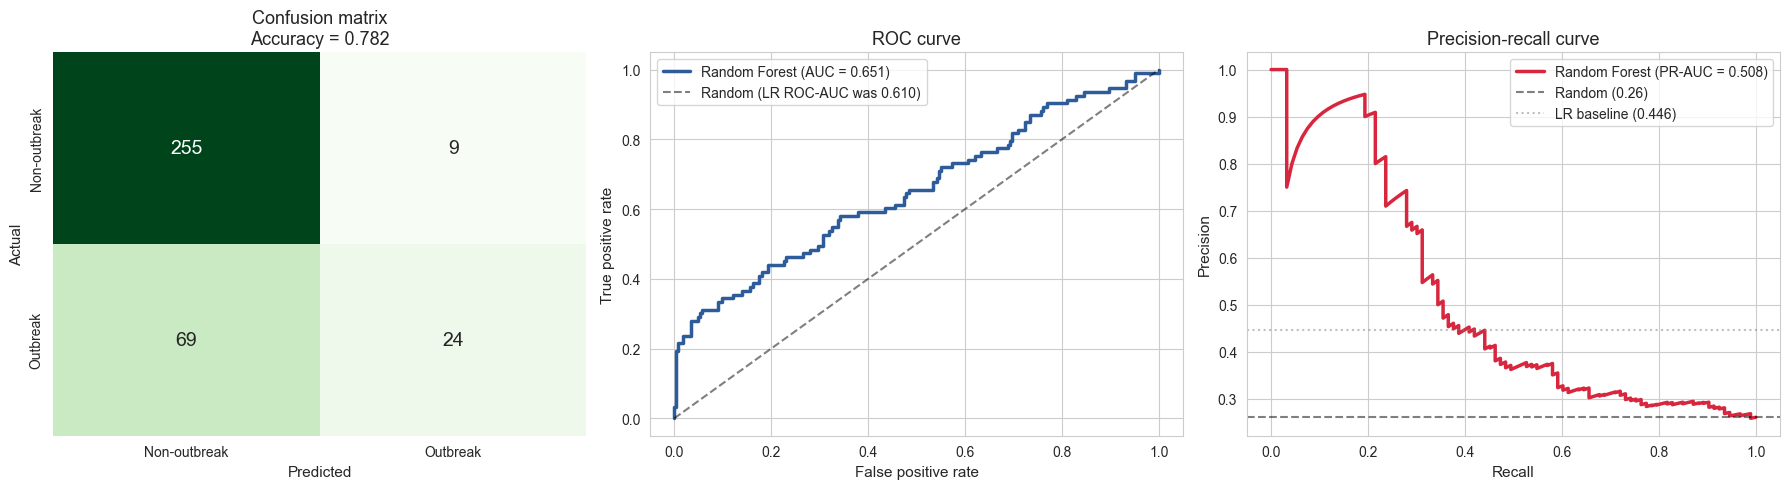

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
cm = confusion_matrix(y, oof_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Non-outbreak', 'Outbreak'], yticklabels=['Non-outbreak', 'Outbreak'],
            cbar=False, annot_kws={'size': 14})
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion matrix\nAccuracy = {metrics["accuracy"]:.3f}')

ax = axes[1]
fpr, tpr, _ = roc_curve(y, oof_proba)
ax.plot(fpr, tpr, color='#2E5C9A', linewidth=2.5, label=f'Random Forest (AUC = {metrics["roc_auc"]:.3f})')
# Overlay LR for comparison if available
if lr_metrics_path.exists():
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label=f'Random (LR ROC-AUC was {lr_metrics["cv_metrics"]["roc_auc"]:.3f})')
else:
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('ROC curve'); ax.legend()

ax = axes[2]
prec, rec, _ = precision_recall_curve(y, oof_proba)
ax.plot(rec, prec, color='#D7263D', linewidth=2.5, label=f'Random Forest (PR-AUC = {metrics["pr_auc"]:.3f})')
ax.axhline(positive_rate, color='black', linestyle='--', alpha=0.5, label=f'Random ({positive_rate:.2f})')
if lr_metrics_path.exists():
    ax.axhline(lr_metrics["cv_metrics"]["pr_auc"], color='gray', linestyle=':', alpha=0.5,
               label=f'LR baseline ({lr_metrics["cv_metrics"]["pr_auc"]:.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-recall curve'); ax.legend()

plt.tight_layout(); plt.show()

## 7. Calibration — Critical for SIR Coupling

Random Forest probabilities are **typically over-confident at extremes** (push values toward 0 and 1). The SIR simulation needs reliable probabilities, so we evaluate calibration both before and after isotonic regression.

If calibration improves significantly with isotonic regression, we save the calibrated model as the production artifact.

Brier score:
  Uncalibrated RF: 0.175
  Isotonic-calibrated RF: 0.160
  Improvement: +0.015


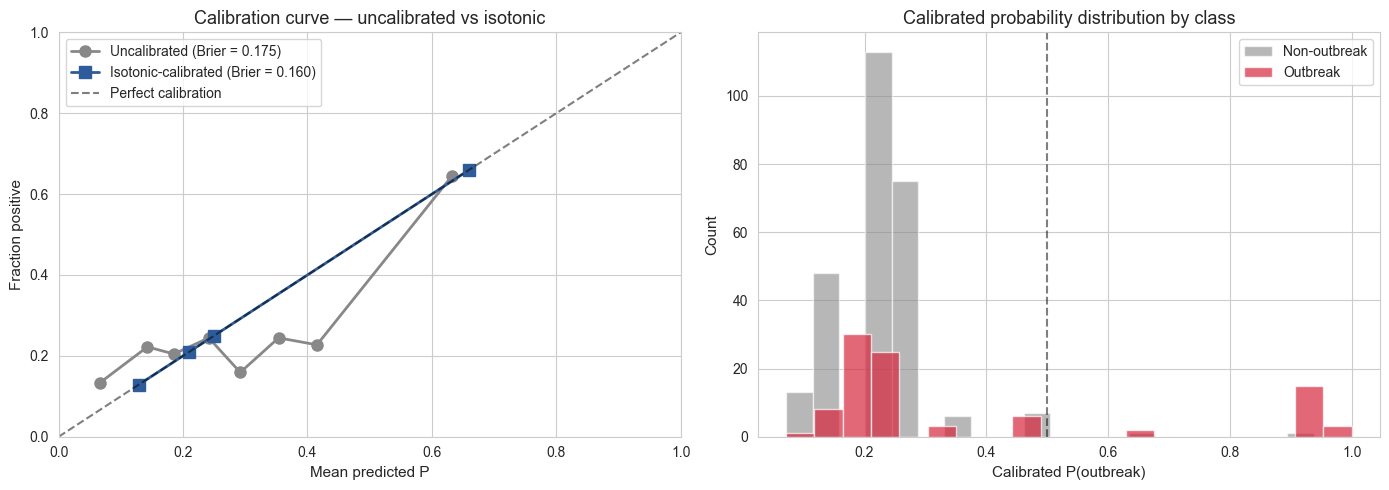

In [8]:
# Uncalibrated RF — already have oof_proba
prob_true_uncal, prob_pred_uncal = calibration_curve(y, oof_proba, n_bins=8, strategy='quantile')
brier_uncal = brier_score_loss(y, oof_proba)

# Calibrate post-hoc using isotonic regression on the OOF probabilities
# This is a simpler approach than nested CV with CalibratedClassifierCV
# (which has issues with groups parameter in newer sklearn)
from sklearn.isotonic import IsotonicRegression
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(oof_proba, y)
calibrated_proba = iso.predict(oof_proba)

prob_true_cal, prob_pred_cal = calibration_curve(y, calibrated_proba, n_bins=8, strategy='quantile')
brier_cal = brier_score_loss(y, calibrated_proba)

print(f'Brier score:')
print(f'  Uncalibrated RF: {brier_uncal:.3f}')
print(f'  Isotonic-calibrated RF: {brier_cal:.3f}')
print(f'  Improvement: {brier_uncal - brier_cal:+.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(prob_pred_uncal, prob_true_uncal, marker='o', color='#888888', linewidth=2,
        markersize=8, label=f'Uncalibrated (Brier = {brier_uncal:.3f})')
ax.plot(prob_pred_cal, prob_true_cal, marker='s', color='#2E5C9A', linewidth=2,
        markersize=8, label=f'Isotonic-calibrated (Brier = {brier_cal:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.set_xlabel('Mean predicted P'); ax.set_ylabel('Fraction positive')
ax.set_title('Calibration curve — uncalibrated vs isotonic')
ax.legend(); ax.set_xlim(0, 1); ax.set_ylim(0, 1)

ax = axes[1]
ax.hist(calibrated_proba[y == 0], bins=20, alpha=0.6, color='#888888', label='Non-outbreak', edgecolor='white')
ax.hist(calibrated_proba[y == 1], bins=20, alpha=0.7, color='#D7263D', label='Outbreak', edgecolor='white')
ax.axvline(0.5, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Calibrated P(outbreak)'); ax.set_ylabel('Count')
ax.set_title('Calibrated probability distribution by class')
ax.legend()

plt.tight_layout(); plt.show()

## 8. Feature Importance — Gini vs Permutation

**Gini importance** (built-in `feature_importances_`) is biased toward features with many unique values. **Permutation importance** is more honest: it measures the drop in CV accuracy when each feature's values are shuffled, breaking its predictive signal.

We report both for transparency.

In [9]:
# Gini importance
gini_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Permutation importance — more reliable
perm = permutation_importance(model, X, y, n_repeats=30, random_state=42, n_jobs=-1, scoring='average_precision')
perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
perm_std = pd.Series(perm.importances_std, index=X.columns)

importance_df = pd.DataFrame({
    'gini': gini_imp,
    'permutation': perm_imp,
    'perm_std': perm_std,
}).sort_values('permutation', ascending=False).round(4)

print('Feature importance (sorted by permutation importance):\n')
print(importance_df.to_string())

Feature importance (sorted by permutation importance):

                        gini  permutation  perm_std
disease_FLU           0.0635       0.0882    0.0090
pct_foreign_born      0.1783       0.0715    0.0114
public_transport_pct  0.1639       0.0573    0.0127
avg_household_size    0.1708       0.0543    0.0127
pop_density_per_sqmi  0.1672       0.0454    0.0097
disease_RSV           0.0342       0.0438    0.0070
pct_elderly           0.1544       0.0398    0.0097
state_NY              0.0354       0.0151    0.0044
state_PA              0.0291       0.0062    0.0021
state_DE              0.0032       0.0000    0.0000


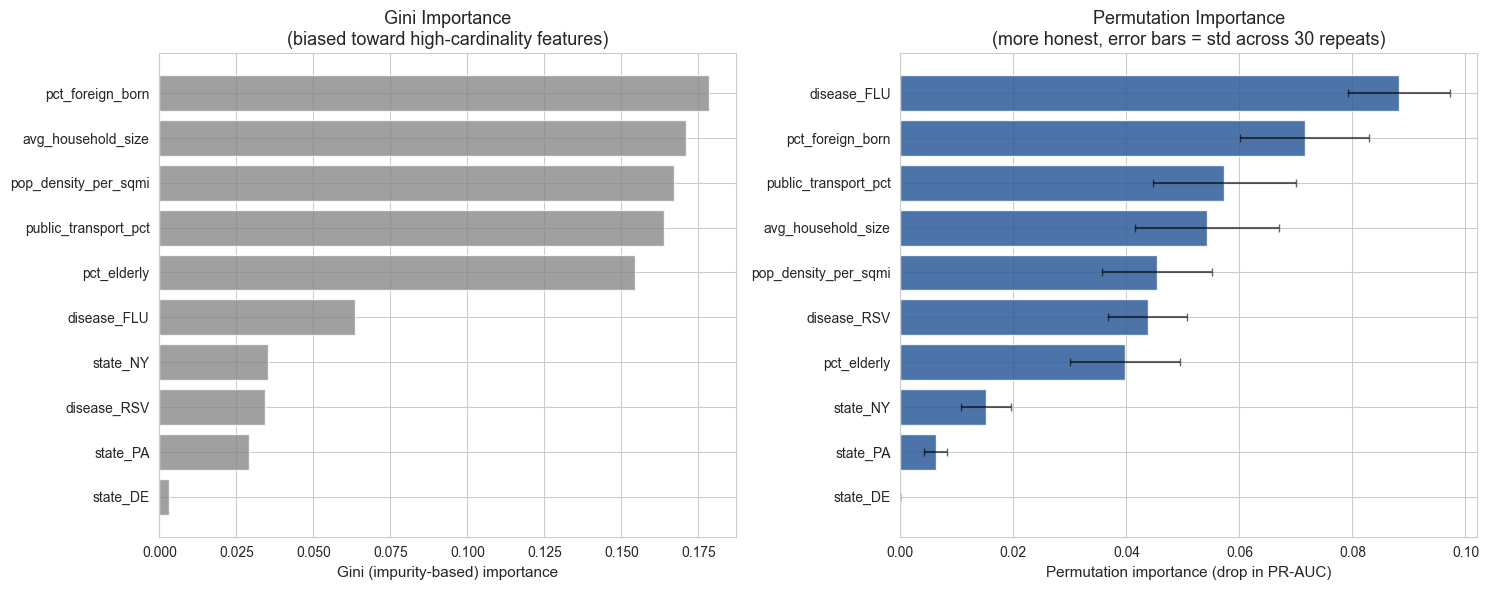

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gini
ax = axes[0]
sorted_g = gini_imp.sort_values()
ax.barh(sorted_g.index, sorted_g.values, color='#888888', edgecolor='white', alpha=0.8)
ax.set_xlabel('Gini (impurity-based) importance')
ax.set_title('Gini Importance\n(biased toward high-cardinality features)')

# Permutation
ax = axes[1]
sorted_p = perm_imp.sort_values()
sorted_std = perm_std.reindex(sorted_p.index)
ax.barh(sorted_p.index, sorted_p.values, xerr=sorted_std.values,
        color='#2E5C9A', edgecolor='white', alpha=0.85,
        error_kw={'ecolor': 'black', 'capsize': 3, 'alpha': 0.6})
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Permutation importance (drop in PR-AUC)')
ax.set_title('Permutation Importance\n(more honest, error bars = std across 30 repeats)')

plt.tight_layout(); plt.show()

## 9. Per-Disease Performance Breakdown

In [11]:
per_pred = pd.DataFrame({
    'fips': master['fips'],
    'disease': master['disease'],
    'state': master['state'],
    'true': y,
    'pred': oof_pred,
    'proba': oof_proba,
    'proba_calibrated': calibrated_proba,
})

per_disease = per_pred.groupby('disease').apply(lambda g: pd.Series({
    'n': len(g),
    'positives': g['true'].sum(),
    'pr_auc': average_precision_score(g['true'], g['proba']) if g['true'].sum() > 0 else np.nan,
    'pr_auc_calibrated': average_precision_score(g['true'], g['proba_calibrated']) if g['true'].sum() > 0 else np.nan,
    'roc_auc': roc_auc_score(g['true'], g['proba']) if g['true'].nunique() == 2 else np.nan,
    'accuracy': accuracy_score(g['true'], g['pred']),
}), include_groups=False).round(3)

print('Per-disease performance:\n')
print(per_disease.to_string())

# Compare to LR per-disease
if lr_metrics_path.exists():
    print(f'\n=== RF vs LR per disease (PR-AUC) ===')
    lr_per = lr_metrics.get('per_disease_performance', {})
    for disease in per_disease.index:
        lr_v = lr_per.get(disease, {}).get('pr_auc', np.nan)
        rf_v = per_disease.loc[disease, 'pr_auc']
        delta = rf_v - lr_v if not np.isnan(lr_v) else np.nan
        print(f'  {disease}: LR = {lr_v:.3f}  →  RF = {rf_v:.3f}  ({delta:+.3f})')

Per-disease performance:

             n  positives  pr_auc  pr_auc_calibrated  roc_auc  accuracy
disease                                                                
COVID    140.0       36.0   0.664              0.646    0.724     0.836
FLU      141.0       37.0   0.445              0.444    0.621     0.759
RSV       76.0       20.0   0.308              0.312    0.533     0.724

=== RF vs LR per disease (PR-AUC) ===
  COVID: LR = 0.554  →  RF = 0.664  (+0.110)
  FLU: LR = 0.479  →  RF = 0.445  (-0.034)
  RSV: LR = 0.228  →  RF = 0.308  (+0.080)


## 10. Save Model + Metrics

In [12]:
# Save the model. We use the uncalibrated RF + the isotonic regressor (fit on OOF)
# as the production artifact. To predict, the inference pipeline does:
#   raw = model.predict_proba(X)[:, 1]
#   calibrated = iso.predict(raw)

artifact = {
    'model': model,  # uncalibrated RF
    'isotonic_calibrator': iso,  # apply this to predict_proba output
    'scaler': scaler,
    'feature_names': list(X.columns),
    'best_params': grid.best_params_,
    'metrics': metrics,
}
with open(MODELS_DIR / 'rf_model.pkl', 'wb') as f:
    pickle.dump(artifact, f)
print(f'✅ models/rf_model.pkl')

# Metrics export — same schema as lr_metrics.json
metrics_export = {
    'model': 'RandomForest',
    'dataset': 'master_stacked.csv',
    'n_observations': int(len(y)),
    'n_features': int(X.shape[1]),
    'positive_class_rate': float(y.mean()),
    'cv_strategy': 'StratifiedGroupKFold(n_splits=5, groups=fips)',
    'best_params': {k: (str(v) if v is None else v) for k, v in grid.best_params_.items()},
    'class_weight': 'balanced',
    'cv_metrics': {k: float(v) for k, v in metrics.items()},
    'cv_metrics_calibrated': {
        'brier': float(brier_cal),
    },
    'baseline_pr_auc': float(positive_rate),
    'feature_importance': {
        'gini': {f: float(v) for f, v in gini_imp.items()},
        'permutation': {f: float(v) for f, v in perm_imp.items()},
        'permutation_std': {f: float(v) for f, v in perm_std.items()},
    },
    'per_disease_performance': per_disease.to_dict(orient='index'),
}
with open(MODELS_DIR / 'rf_metrics.json', 'w') as f:
    json.dump(metrics_export, f, indent=2)
print(f'✅ models/rf_metrics.json')

✅ models/rf_model.pkl
✅ models/rf_metrics.json


## 11. Summary

In [13]:
print('=== Random Forest Summary ===\n')
print(f'Dataset: master_stacked.csv ({len(y)} rows: flu + COVID + RSV)')
print(f'Features: {X.shape[1]}')
print(f'Best params: {grid.best_params_}')

print(f'\nHeadline performance (CV with group-CV):')
for k, v in metrics.items():
    print(f'  {k}: {v:.3f}')

print(f'\nCalibration (Brier score):')
print(f'  Uncalibrated: {brier_uncal:.3f}')
print(f'  Isotonic-calibrated: {brier_cal:.3f}')

if lr_metrics_path.exists():
    print(f'\n=== vs Logistic Regression ===')
    delta_pr = metrics['pr_auc'] - lr_metrics['cv_metrics']['pr_auc']
    delta_roc = metrics['roc_auc'] - lr_metrics['cv_metrics']['roc_auc']
    print(f'  PR-AUC: LR {lr_metrics["cv_metrics"]["pr_auc"]:.3f} → RF {metrics["pr_auc"]:.3f} ({delta_pr:+.3f})')
    print(f'  ROC-AUC: LR {lr_metrics["cv_metrics"]["roc_auc"]:.3f} → RF {metrics["roc_auc"]:.3f} ({delta_roc:+.3f})')

print(f'\n👉 Next: Notebook 06 (XGBoost) — typically best on tabular data.')

=== Random Forest Summary ===

Dataset: master_stacked.csv (357 rows: flu + COVID + RSV)
Features: 10
Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 500}

Headline performance (CV with group-CV):
  accuracy: 0.782
  precision: 0.727
  recall: 0.258
  f1: 0.381
  roc_auc: 0.651
  pr_auc: 0.508
  brier: 0.175

Calibration (Brier score):
  Uncalibrated: 0.175
  Isotonic-calibrated: 0.160

=== vs Logistic Regression ===
  PR-AUC: LR 0.446 → RF 0.508 (+0.062)
  ROC-AUC: LR 0.610 → RF 0.651 (+0.042)

👉 Next: Notebook 06 (XGBoost) — typically best on tabular data.


## 12. RF-Specific Feature Selection

The consensus feature set from Notebook 03 used a model-agnostic rule (top-8 in ≥ 3/5 methods across Pearson, Spearman, mutual info, LASSO, RF permutation). Because the linear methods numerically dominate that vote, features important to trees but non-linearly correlated were systematically excluded — for example, `unemployment_rate` ranked **2nd by RF permutation** but 12th by Pearson and was dropped.

Here we re-run feature selection using **RFECV with the RF estimator**, the only method that directly optimises what features are worth to this model family, and compare the resulting PR-AUC against the consensus baseline.

Full candidate matrix: (357, 23)  (18 demo + 2 disease + 3 state)
Running RFECV over all 18 demographic candidates (this takes ~1–2 min)...
Done.

Optimal feature count: 23

Selected (23):
  ✅ pct_foreign_born
  ✅ pop_density_per_sqmi
  ✅ avg_household_size
  ✅ pct_diabetes  ◀ NEW — not in consensus set
  ✅ pct_non_white  ◀ NEW — not in consensus set
  ✅ public_transport_pct
  ✅ pct_elderly
  ✅ median_income  ◀ NEW — not in consensus set
  ✅ unemployment_rate  ◀ NEW — not in consensus set
  ✅ pct_copd  ◀ NEW — not in consensus set
  ✅ median_age  ◀ NEW — not in consensus set
  ✅ pct_checkup  ◀ NEW — not in consensus set
  ✅ pct_obesity  ◀ NEW — not in consensus set
  ✅ pct_chd  ◀ NEW — not in consensus set
  ✅ pct_vaccinated  ◀ NEW — not in consensus set
  ✅ pct_bachelors_plus  ◀ NEW — not in consensus set
  ✅ poverty_rate  ◀ NEW — not in consensus set
  ✅ pct_csmoking  ◀ NEW — not in consensus set
  ✅ disease_FLU
  ✅ disease_RSV
  ✅ state_DE
  ✅ state_NY
  ✅ state_PA

Dropped (0):

  

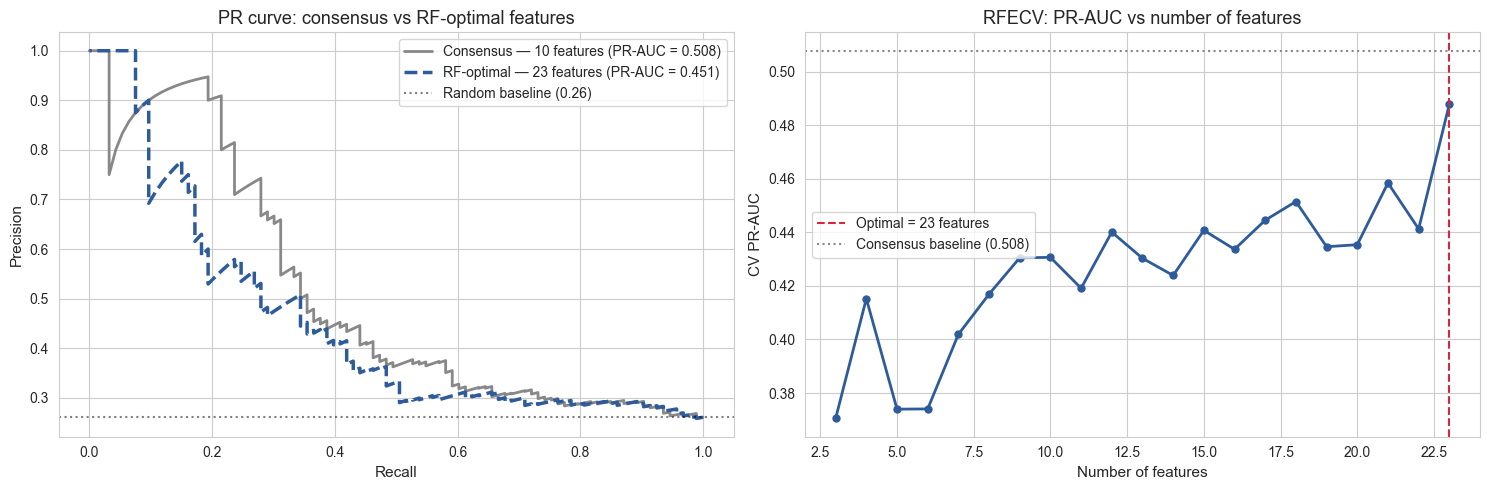

In [14]:
from sklearn.feature_selection import RFECV

# 1. Full candidate matrix — all 18 demographic features from NB03 rankings + locked dummies
ALL_CANDIDATES = [r['feature'] for r in fc['rankings']]
scaler_full = StandardScaler()
demo_full = pd.DataFrame(
    scaler_full.fit_transform(master[ALL_CANDIDATES]),
    columns=ALL_CANDIDATES, index=master.index,
)
X_full = pd.concat([demo_full, disease_X[DISEASE_DUMMIES], state_X[STATE_DUMMIES]], axis=1)
print(f'Full candidate matrix: {X_full.shape}  '
      f'({len(ALL_CANDIDATES)} demo + {len(DISEASE_DUMMIES)} disease + {len(STATE_DUMMIES)} state)')

# 2. RFECV with a lighter RF (n_estimators=100) to find optimal subset;
#    best hyperparams applied at the refit stage below.
rf_rfe = RandomForestClassifier(
    n_estimators=100,
    max_depth=grid.best_params_['max_depth'],
    min_samples_split=grid.best_params_['min_samples_split'],
    max_features=grid.best_params_['max_features'],
    class_weight='balanced',
    random_state=42,
    n_jobs=1,  # RFECV parallelises over CV folds; avoid nested parallelism
)
rfecv = RFECV(
    estimator=rf_rfe,
    step=1,
    cv=StratifiedGroupKFold(n_splits=5),
    scoring='average_precision',
    min_features_to_select=3,
    n_jobs=-1,
)
print('Running RFECV over all 18 demographic candidates (this takes ~1–2 min)...')
rfecv.fit(X_full, y, groups=groups)
print('Done.')

# 3. Report selected vs dropped features
rf_optimal_features = X_full.columns[rfecv.support_].tolist()
dropped_features    = X_full.columns[~rfecv.support_].tolist()

print(f'\nOptimal feature count: {rfecv.n_features_}')
print(f'\nSelected ({len(rf_optimal_features)}):')
for f in rf_optimal_features:
    tag = '  ◀ NEW — not in consensus set' if f not in X.columns else ''
    print(f'  ✅ {f}{tag}')
print(f'\nDropped ({len(dropped_features)}):')
for f in dropped_features:
    tag = '  ◀ was in consensus set' if f in X.columns else ''
    print(f'  ✗ {f}{tag}')

# 4. Refit with full best_params on the optimal feature set and evaluate
X_opt = X_full[rf_optimal_features]
rf_opt = RandomForestClassifier(**grid.best_params_, class_weight='balanced', random_state=42, n_jobs=-1)
oof_proba_opt = cross_val_predict(
    rf_opt, X_opt, y,
    cv=StratifiedGroupKFold(n_splits=5),
    method='predict_proba',
    groups=groups,
)[:, 1]
pr_auc_opt  = average_precision_score(y, oof_proba_opt)
roc_auc_opt = roc_auc_score(y, oof_proba_opt)

print(f'\n{"=" * 55}')
print(f'{"":22s}  PR-AUC  ROC-AUC  N features')
print(f'{"Consensus (NB03)":<22s}  {metrics["pr_auc"]:.3f}    {metrics["roc_auc"]:.3f}    {X.shape[1]}')
print(f'{"RF-optimal (RFECV)":<22s}  {pr_auc_opt:.3f}    {roc_auc_opt:.3f}    {len(rf_optimal_features)}')
print(f'{"PR-AUC gain":<22s}  {pr_auc_opt - metrics["pr_auc"]:+.3f}')
print(f'{"=" * 55}')

# 5. Plots: PR curve comparison + RFECV score-vs-n-features curve
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
prec_con, rec_con, _ = precision_recall_curve(y, oof_proba)
prec_opt, rec_opt, _ = precision_recall_curve(y, oof_proba_opt)
ax.plot(rec_con, prec_con, color='#888888', linewidth=2,
        label=f'Consensus — 10 features (PR-AUC = {metrics["pr_auc"]:.3f})')
ax.plot(rec_opt, prec_opt, color='#2E5C9A', linewidth=2.5, linestyle='--',
        label=f'RF-optimal — {len(rf_optimal_features)} features (PR-AUC = {pr_auc_opt:.3f})')
ax.axhline(positive_rate, color='black', linestyle=':', alpha=0.5,
           label=f'Random baseline ({positive_rate:.2f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('PR curve: consensus vs RF-optimal features')
ax.legend()

ax = axes[1]
cv_scores = rfecv.cv_results_['mean_test_score']
n_range   = range(rfecv.min_features_to_select,
                  rfecv.min_features_to_select + len(cv_scores))
ax.plot(list(n_range), cv_scores, marker='o', color='#2E5C9A', linewidth=2, markersize=5)
ax.axvline(rfecv.n_features_, color='#D7263D', linestyle='--', linewidth=1.5,
           label=f'Optimal = {rfecv.n_features_} features')
ax.axhline(metrics['pr_auc'], color='#888888', linestyle=':', linewidth=1.5,
           label=f'Consensus baseline ({metrics["pr_auc"]:.3f})')
ax.set_xlabel('Number of features'); ax.set_ylabel('CV PR-AUC')
ax.set_title('RFECV: PR-AUC vs number of features')
ax.legend()

plt.tight_layout(); plt.show()

## 13. Rerun with Top-5 Permutation-Important Features

Top-5 features by permutation importance:
  1. disease_FLU  (perm importance = 0.0882)
  2. pct_foreign_born  (perm importance = 0.0715)
  3. public_transport_pct  (perm importance = 0.0573)
  4. avg_household_size  (perm importance = 0.0543)
  5. pop_density_per_sqmi  (perm importance = 0.0454)

                      PR-AUC  ROC-AUC  F1     Features
Consensus (10)        0.508    0.651    0.381  10
Top-5 perm            0.482    0.640    0.409  5
PR-AUC delta          -0.026


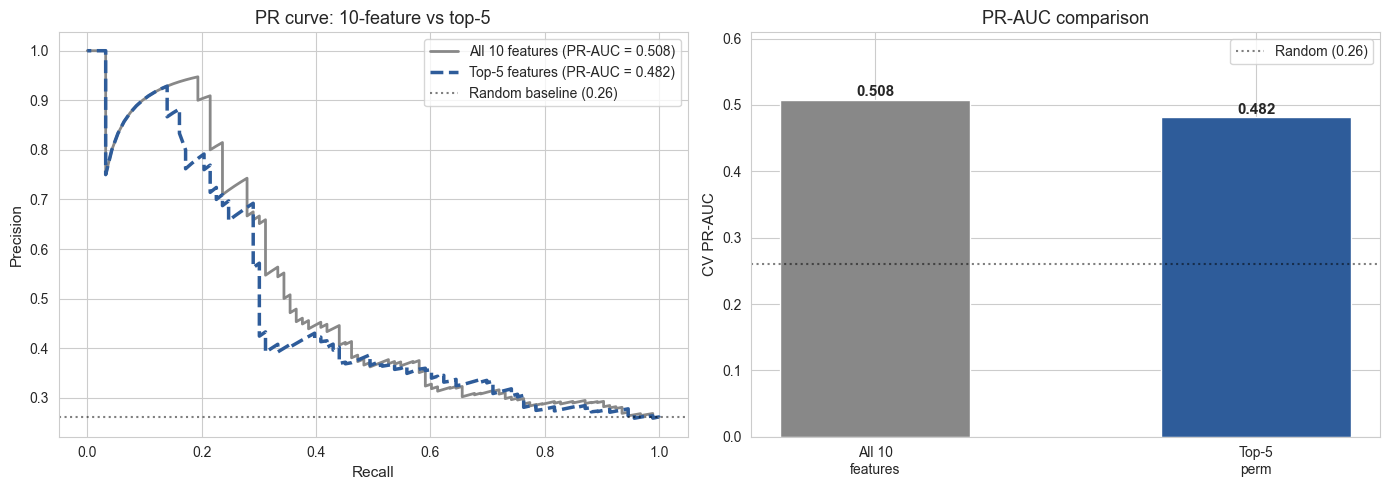

In [15]:
top5_features = perm_imp.nlargest(5).index.tolist()
print('Top-5 features by permutation importance:')
for i, f in enumerate(top5_features, 1):
    print(f'  {i}. {f}  (perm importance = {perm_imp[f]:.4f})')

X_top5 = X[top5_features]
rf_top5 = RandomForestClassifier(**grid.best_params_, class_weight='balanced', random_state=42, n_jobs=-1)
oof_proba_top5 = cross_val_predict(
    rf_top5, X_top5, y,
    cv=StratifiedGroupKFold(n_splits=5),
    method='predict_proba',
    groups=groups,
)[:, 1]
oof_pred_top5 = (oof_proba_top5 >= 0.5).astype(int)

pr_auc_top5  = average_precision_score(y, oof_proba_top5)
roc_auc_top5 = roc_auc_score(y, oof_proba_top5)
f1_top5      = f1_score(y, oof_pred_top5, zero_division=0)

print(f'\n{"=" * 52}')
print(f'{"":20s}  PR-AUC  ROC-AUC  F1     Features')
print(f'{"Consensus (10)":<20s}  {metrics["pr_auc"]:.3f}    {metrics["roc_auc"]:.3f}    {metrics["f1"]:.3f}  10')
print(f'{"Top-5 perm":<20s}  {pr_auc_top5:.3f}    {roc_auc_top5:.3f}    {f1_top5:.3f}  5')
print(f'{"PR-AUC delta":<20s}  {pr_auc_top5 - metrics["pr_auc"]:+.3f}')
print(f'{"=" * 52}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
prec_10, rec_10, _  = precision_recall_curve(y, oof_proba)
prec_5,  rec_5,  _  = precision_recall_curve(y, oof_proba_top5)
ax.plot(rec_10, prec_10, color='#888888', linewidth=2,
        label=f'All 10 features (PR-AUC = {metrics["pr_auc"]:.3f})')
ax.plot(rec_5,  prec_5,  color='#2E5C9A', linewidth=2.5, linestyle='--',
        label=f'Top-5 features (PR-AUC = {pr_auc_top5:.3f})')
ax.axhline(positive_rate, color='black', linestyle=':', alpha=0.5,
           label=f'Random baseline ({positive_rate:.2f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('PR curve: 10-feature vs top-5')
ax.legend()

ax = axes[1]
bars = pd.Series({
    'All 10\nfeatures': metrics['pr_auc'],
    'Top-5\nperm': pr_auc_top5,
})
colors = ['#888888', '#2E5C9A']
ax.bar(bars.index, bars.values, color=colors, edgecolor='white', width=0.5)
ax.axhline(positive_rate, color='black', linestyle=':', alpha=0.5, label=f'Random ({positive_rate:.2f})')
ax.set_ylabel('CV PR-AUC')
ax.set_title('PR-AUC comparison')
ax.set_ylim(0, max(bars.values) * 1.2)
for i, (label, val) in enumerate(bars.items()):
    ax.text(i, val + 0.005, f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.legend()

plt.tight_layout(); plt.show()